In [1]:
# ライブラリーのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# データの読み込み
data_train = pd.read_csv('../data/train.csv')
data_test = pd.read_csv('../data/test.csv')
data_submission = pd.read_csv('../data/sample_submission.csv')

In [3]:
data_train.tail(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594184,594184,Female,1,Yes,No,40,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,103.90,4108.15,Yes
594185,594185,Male,0,Yes,No,39,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,3452.55,Yes
594186,594186,Female,1,No,No,29,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),95.40,2698.35,No
594187,594187,Male,0,Yes,Yes,3,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Electronic check,80.45,244.45,Yes
594188,594188,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),20.25,669.05,No
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


In [4]:
data_test.head(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65
5,594199,Male,0,No,No,24,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.95,1406.20
6,594200,Female,0,No,No,1,Yes,No,Fiber optic,Yes,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,78.60,78.60
7,594201,Female,0,No,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),60.35,3825.20
8,594202,Female,0,Yes,No,55,Yes,Yes,Fiber optic,No,No,No,No,No,No,One year,No,Credit card (automatic),75.45,4459.15
9,594203,Female,0,No,No,50,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.85,4533.90


In [5]:
# 訓練データのid,MonthlyCharges、TotalCharges以外のカラムのユニーク値の件数と内容を確認
target_cols = data_train.drop(['id', 'MonthlyCharges', 'TotalCharges'], axis=1).columns

unique_summary = pd.DataFrame({
    'nunique': data_train[target_cols].nunique(dropna=False),
    'unique_values': data_train[target_cols].apply(lambda s: s.drop_duplicates().tolist())
})

unique_summary

,nunique,unique_values
gender,2,"[Male, Female]"
SeniorCitizen,2,"[0, 1]"
Partner,2,"[Yes, No]"
Dependents,2,"[Yes, No]"
tenure,72,"[29, 58, 1, 24, 72, 55, 13, 67, 33, 63, 3, 31,..."
PhoneService,2,"[Yes, No]"
MultipleLines,3,"[No, Yes, No phone service]"
InternetService,3,"[DSL, Fiber optic, No]"
OnlineSecurity,3,"[Yes, No, No internet service]"
OnlineBackup,3,"[No, Yes, No internet service]"


In [6]:
data_submission.head(10)

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0
5,594199,0
6,594200,0
7,594201,0
8,594202,0
9,594203,0


# データの大まかな確認

In [27]:
# ydata-profilingのインストール
!pip install ydata-profiling
from ydata_profiling import ProfileReport

data_train.profile_report()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:04<00:00,  5.01it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [28]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

## 各々の特徴量と、目的の変数（Churn）との関係性を確認

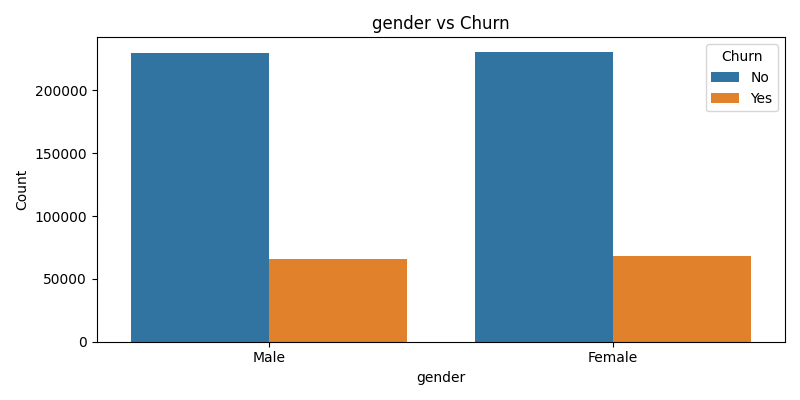

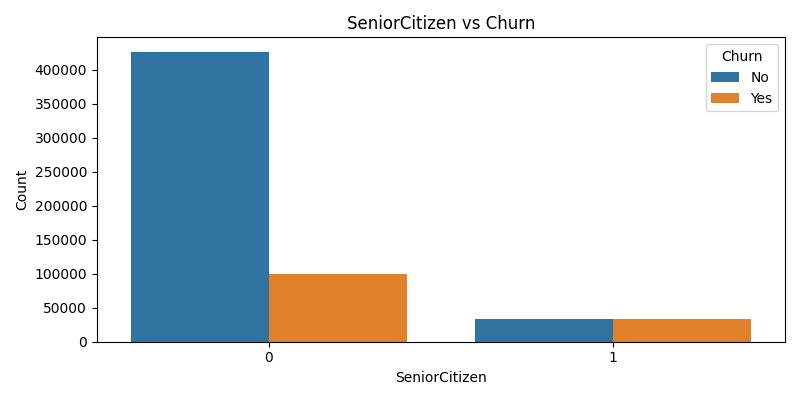

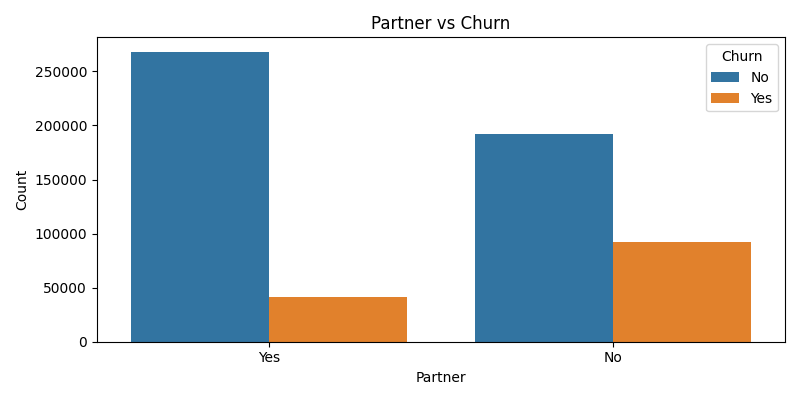

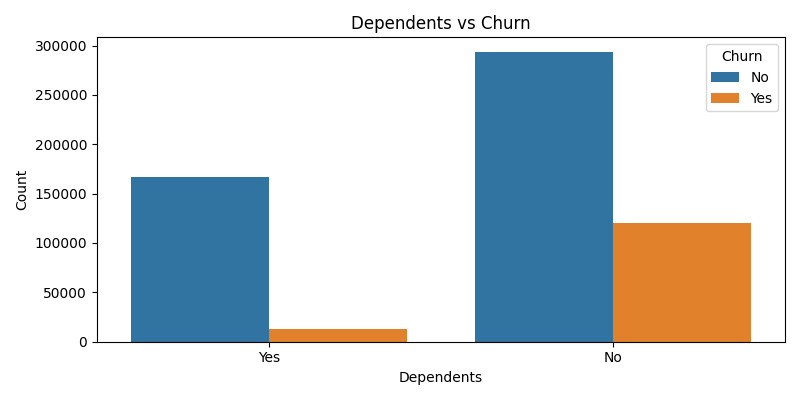

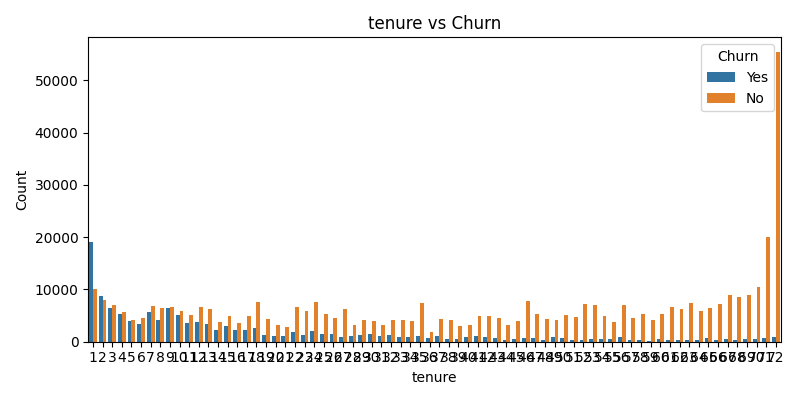

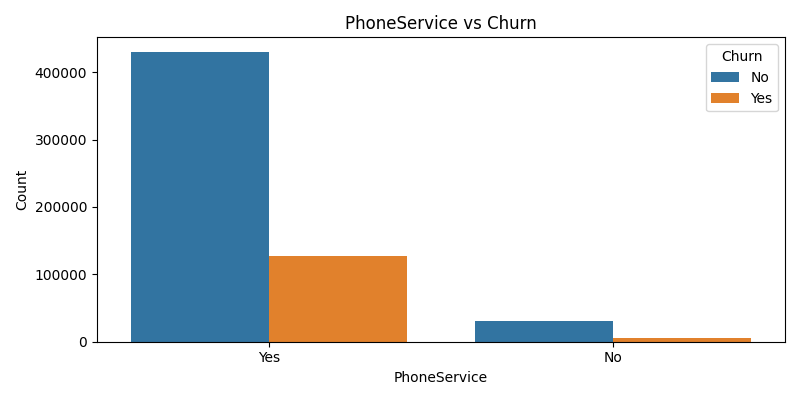

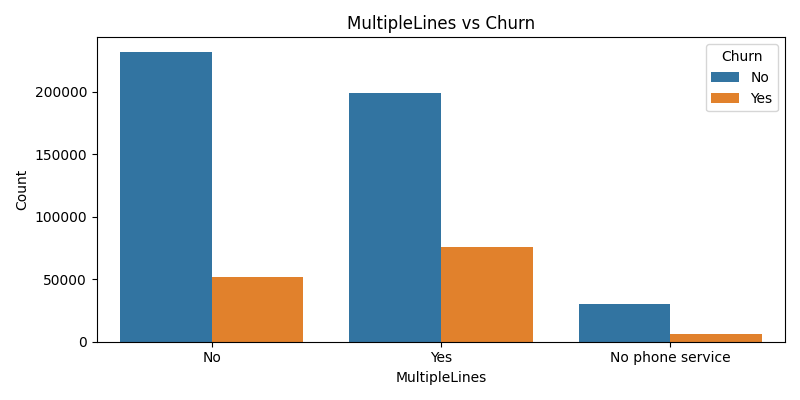

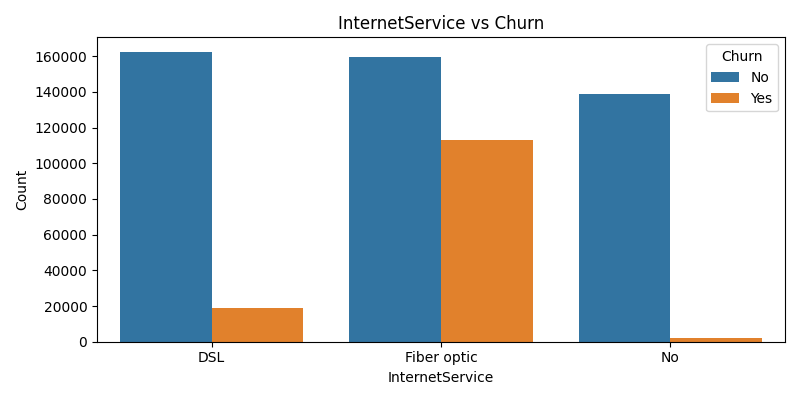

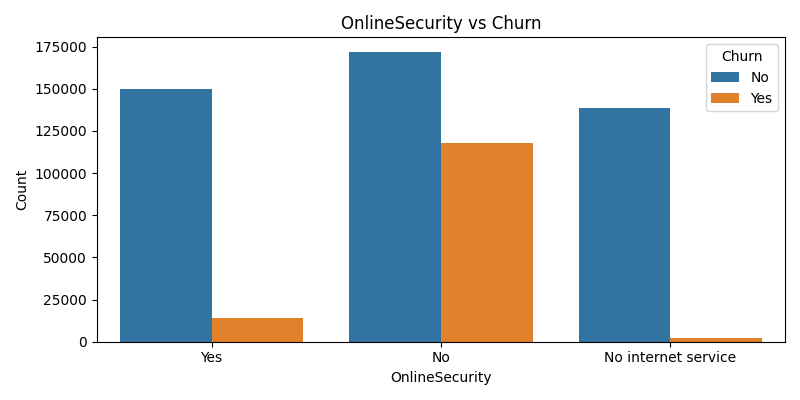

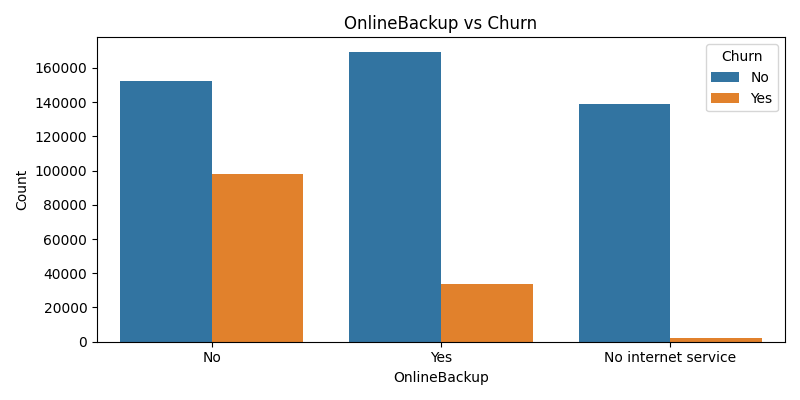

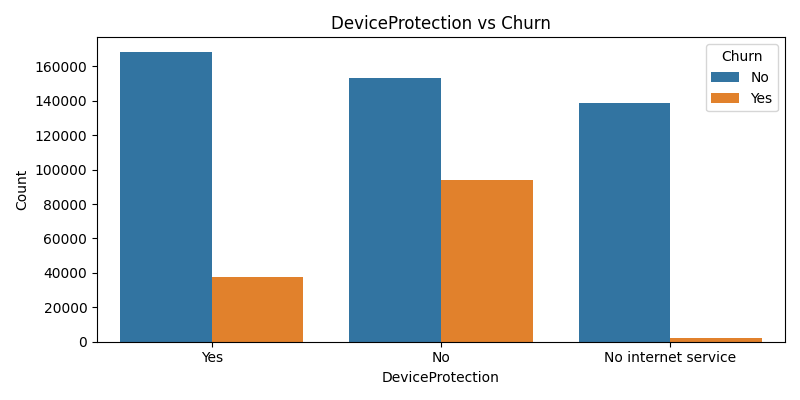

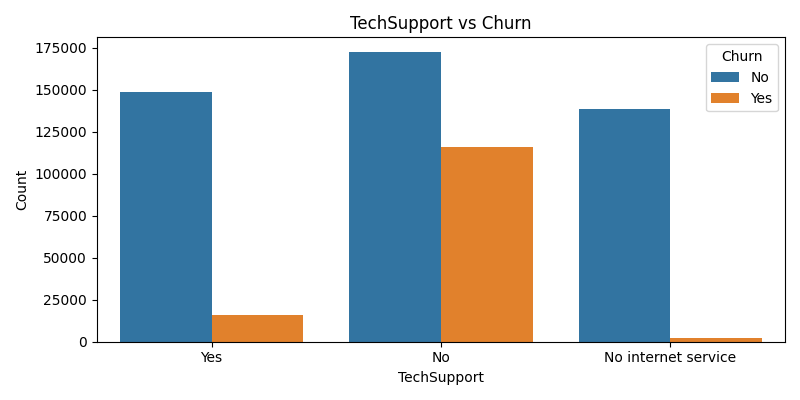

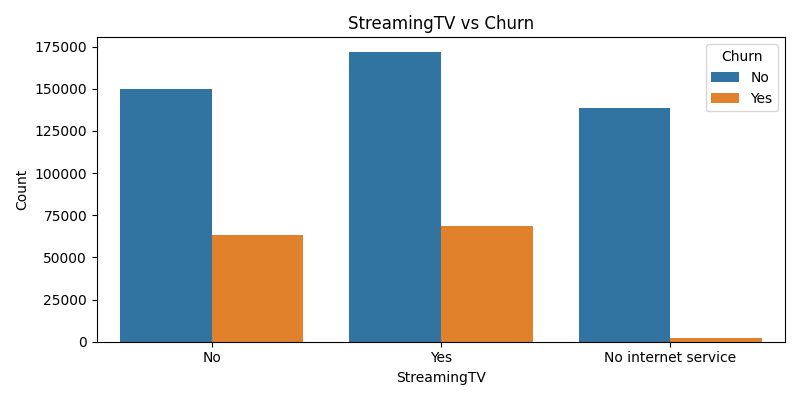

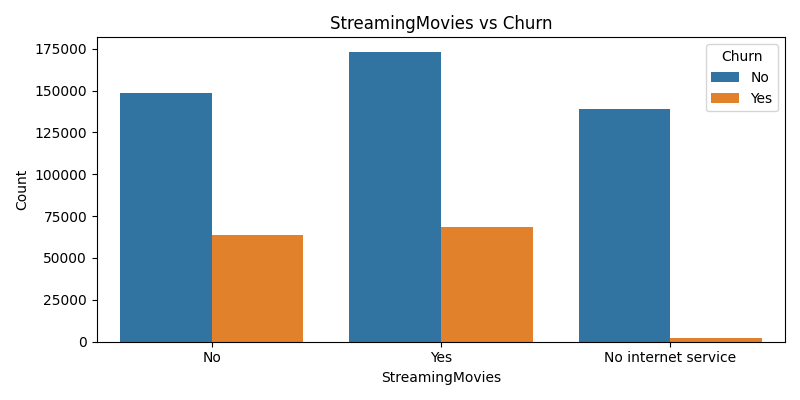

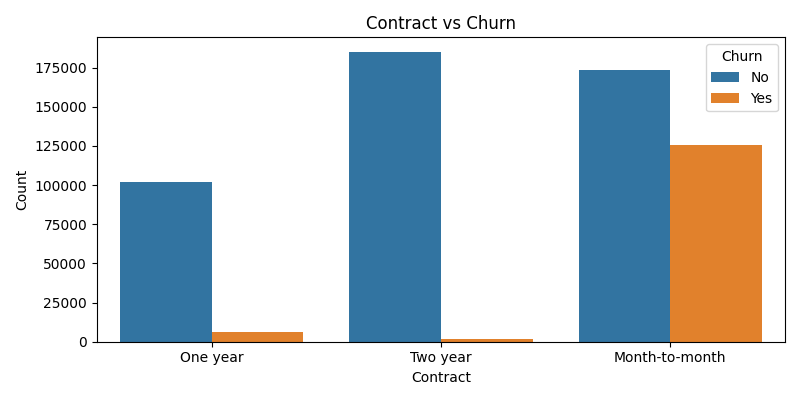

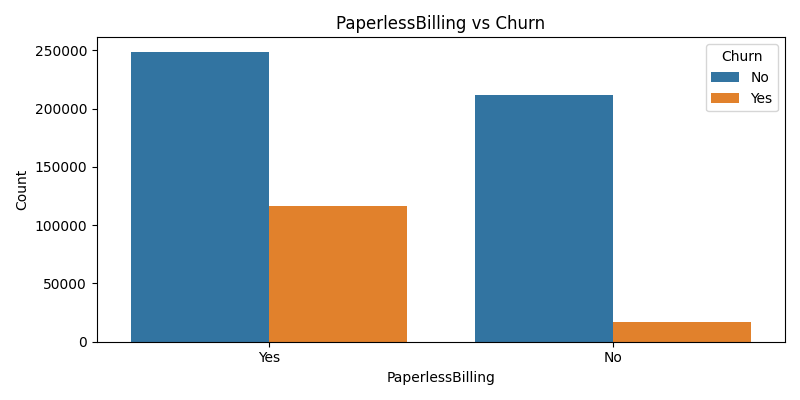

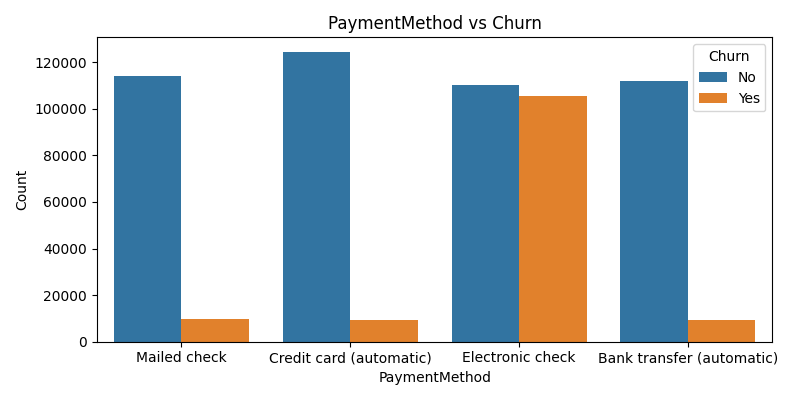

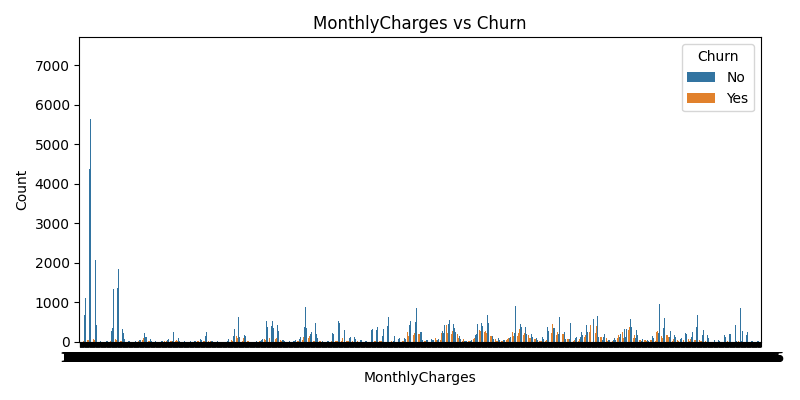

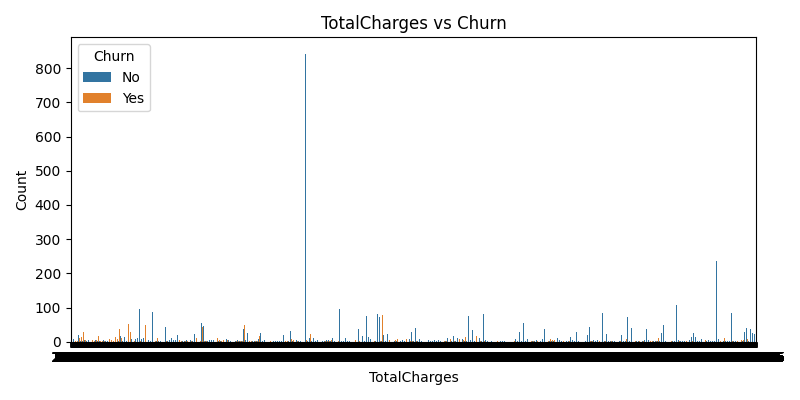

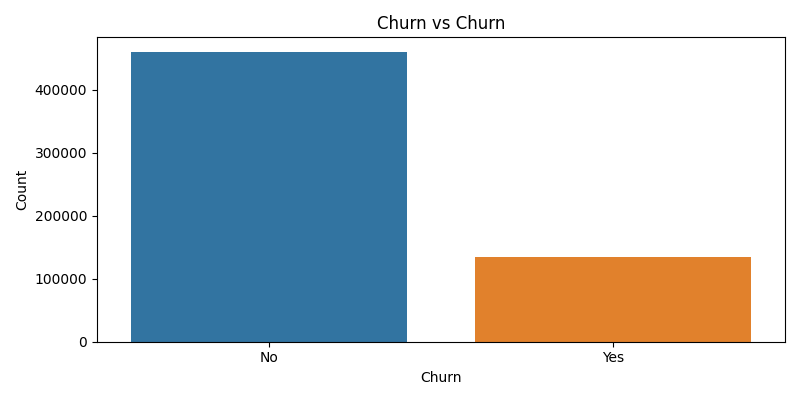

In [29]:
# 各々の特徴量（genderからTotalCharges）と、目的の変数（Churn）との関係性を確認するためのグラフを作成

# 理想
# 有意差をアスタリスクの数で表示
# アスタリスクの数は、p値の大きさに応じて以下のように設定
# p < 0.001: '***'
# 0.001 <= p < 0.01: '**'
# 0.01 <= p < 0.05: '*'

import io
from IPython.display import Image, display # 
import matplotlib.pyplot as plt
import seaborn as sns

for column in data_train.columns[1:]: # id列を除く全ての列に対してループ
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.countplot(x=column, hue='Churn', data=data_train, ax=ax)
    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')
    if ax.get_legend() is not None: # 凡例が存在する場合にタイトルを設定
        ax.get_legend().set_title('Churn')

    buf = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buf, format='png')
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

# データの統合、分割、削除、新特徴量生成の検討

In [7]:
# 教師用データとテストデータ、双方にエンジニアリングを行うため、一旦一つに結合する。
data_all = pd.concat([data_train, data_test], sort = False)
data_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848849 entries, 0 to 254654
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                848849 non-null  int64  
 1   gender            848849 non-null  object 
 2   SeniorCitizen     848849 non-null  int64  
 3   Partner           848849 non-null  object 
 4   Dependents        848849 non-null  object 
 5   tenure            848849 non-null  int64  
 6   PhoneService      848849 non-null  object 
 7   MultipleLines     848849 non-null  object 
 8   InternetService   848849 non-null  object 
 9   OnlineSecurity    848849 non-null  object 
 10  OnlineBackup      848849 non-null  object 
 11  DeviceProtection  848849 non-null  object 
 12  TechSupport       848849 non-null  object 
 13  StreamingTV       848849 non-null  object 
 14  StreamingMovies   848849 non-null  object 
 15  Contract          848849 non-null  object 
 16  PaperlessBilling  848849 

## PhoneService と MultipleLines の統合

In [8]:
# PhoneService と MultipleLines を1列に統合

required_cols = ["PhoneService", "MultipleLines"]
missing = [c for c in required_cols if c not in data_all.columns]
if missing:
    raise ValueError(f"不足カラムがあります: {missing}")

data_all["PhoneLineStatus"] = np.select(
    [
        data_all["PhoneService"].eq("No"),
        data_all["PhoneService"].eq("Yes") & data_all["MultipleLines"].eq("No"),
        data_all["PhoneService"].eq("Yes") & data_all["MultipleLines"].eq("Yes"),
        data_all["MultipleLines"].eq("No phone service")
    ],
    ["no_phone", "single_line", "multi_line", "no_phone"],
    default="unknown"
)

# 元の2列は統合後に削除
data_all.drop(columns=["PhoneService", "MultipleLines"], inplace=True)

print("PhoneLineStatus を作成し、PhoneService/MultipleLines を削除しました")
print(data_all["PhoneLineStatus"].value_counts(dropna=False))
display(data_all[["PhoneLineStatus"]].head(10))

PhoneLineStatus を作成し、PhoneService/MultipleLines を削除しました
PhoneLineStatus
single_line    403636
multi_line     393430
no_phone        51783
Name: count, dtype: int64


,PhoneLineStatus
0,single_line
1,single_line
2,multi_line
3,single_line
4,single_line
5,single_line
6,single_line
7,multi_line
8,multi_line
9,single_line


## Partner + Dependents の統合検討

In [9]:
# Partner + Dependents を 1 列に統合
# none / partner_only / dependents_only / family の4カテゴリに整理

data_all["HouseholdType"] = np.select( # 条件と結果のリストを指定して新しい列を作成
    [
        data_all["Partner"].eq("No") & data_all["Dependents"].eq("No"),
        data_all["Partner"].eq("Yes") & data_all["Dependents"].eq("No"),
        data_all["Partner"].eq("No") & data_all["Dependents"].eq("Yes"),
        data_all["Partner"].eq("Yes") & data_all["Dependents"].eq("Yes")
    ],
    ["none", "partner_only", "dependents_only", "family"],
    default="unknown"
)

# 元の2列は統合後に削除
data_all.drop(columns=["Partner", "Dependents"], inplace=True)

print("HouseholdType を作成し、Partner/Dependents を削除しました")
print(data_all["HouseholdType"].value_counts(dropna=False))
display(data_all[["HouseholdType"]].head(10))

HouseholdType を作成し、Partner/Dependents を削除しました
HouseholdType
none               385522
family             238401
partner_only       205856
dependents_only     19070
Name: count, dtype: int64


,HouseholdType
0,family
1,family
2,partner_only
3,none
4,none
5,family
6,family
7,partner_only
8,none
9,none


In [10]:
data_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848849 entries, 0 to 254654
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                848849 non-null  int64  
 1   gender            848849 non-null  object 
 2   SeniorCitizen     848849 non-null  int64  
 3   tenure            848849 non-null  int64  
 4   InternetService   848849 non-null  object 
 5   OnlineSecurity    848849 non-null  object 
 6   OnlineBackup      848849 non-null  object 
 7   DeviceProtection  848849 non-null  object 
 8   TechSupport       848849 non-null  object 
 9   StreamingTV       848849 non-null  object 
 10  StreamingMovies   848849 non-null  object 
 11  Contract          848849 non-null  object 
 12  PaperlessBilling  848849 non-null  object 
 13  PaymentMethod     848849 non-null  object 
 14  MonthlyCharges    848849 non-null  float64
 15  TotalCharges      848849 non-null  float64
 16  Churn             594194 

# モデル作成準備

### 目的変数とカテゴリ変数の処理

In [11]:
# Churnを0,1に変換
data_all['Churn'] = data_all['Churn'].replace({'No': 0, 'Yes': 1})
data_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848849 entries, 0 to 254654
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                848849 non-null  int64  
 1   gender            848849 non-null  object 
 2   SeniorCitizen     848849 non-null  int64  
 3   tenure            848849 non-null  int64  
 4   InternetService   848849 non-null  object 
 5   OnlineSecurity    848849 non-null  object 
 6   OnlineBackup      848849 non-null  object 
 7   DeviceProtection  848849 non-null  object 
 8   TechSupport       848849 non-null  object 
 9   StreamingTV       848849 non-null  object 
 10  StreamingMovies   848849 non-null  object 
 11  Contract          848849 non-null  object 
 12  PaperlessBilling  848849 non-null  object 
 13  PaymentMethod     848849 non-null  object 
 14  MonthlyCharges    848849 non-null  float64
 15  TotalCharges      848849 non-null  float64
 16  Churn             594194 

In [12]:
# LightGBMはカテゴリ変数を数値に変換しなくても処理してくれる。
categorical_features = ['gender', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneLineStatus', 'HouseholdType']

In [13]:
# 不要な列を削除
drop_columns = ['id']  # ID列は常に削除
data_all.drop(drop_columns, axis=1, inplace=True)
print(f"削除後の列数: {len(data_all.columns)}")
print(f"欠損値:\n{data_all.isnull().sum()[data_all.isnull().sum() > 0]}")

削除後の列数: 18
欠損値:
Churn    254655
dtype: int64


In [14]:
# 結合したデータを、再度、教師データとテストデータに分ける
# len()で行数を取得、スライスで分割
train_len = len(data_train)
data_all_train = data_all[:train_len]
data_all_test = data_all[train_len:]

print(f"教師データ: {data_all_train.shape}")
print(f"テストデータ: {data_all_test.shape}")

教師データ: (594194, 18)
テストデータ: (254655, 18)


In [15]:
# 目的変数と説明変数を分離（アルゴリズムに投入するための準備）
# y: 目的変数（Churn）、x: 説明変数（それ以外）
target = 'Churn'

# 教師データの分離
y_train = data_all_train[target]
x_train = data_all_train.drop(target, axis=1)

# テストデータの分離（テストにはChurnがない想定だが、念のため確認）
if target in data_all_test.columns:
    y_test = data_all_test[target]
    x_test = data_all_test.drop(target, axis=1)
else:
    x_test = data_all_test.copy()
    print(f"テストデータにはChurn列がありません")

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}")

x_train: (594194, 17), y_train: (594194,)
x_test: (254655, 17)


# モデル作成 LightGBM

In [16]:
# # 用意。学習用データと検証用データに分割する
# from sklearn.model_selection import train_test_split

# # train_test_split関数で、説明・目的変数それぞれに学習用と検証用のデータ、4つを作る↓。
# # test_sizeは検証用データの割合、学習用と検証用のデータを7:3で分ける。
# # 乱数のシード。モデル改善なので、乱数を発生させるブレが出ないように
# # stratify 学習用と検証用のデータで割合を保つ(Survivedの2値が、学習用とテスト用に偏って配置されると検証がうまくいかないので)


# x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

In [17]:
# LightGBM + StratifiedKFold（通常運用用）
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

# 前処理（カテゴリ列をcategory dtypeへ）
x_train_lgb = x_train.copy()
x_test_lgb = x_test.copy()
for col in categorical_features:
    if col in x_train_lgb.columns:
        x_train_lgb[col] = x_train_lgb[col].astype('category')
    if col in x_test_lgb.columns:
        x_test_lgb[col] = x_test_lgb[col].astype('category')

# 基本パラメータ（Optuna結果があれば上書きして利用可能）
base_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'seed': 42,
}
if 'study' in globals() and hasattr(study, 'best_params'):
    params = {**base_params, **study.best_params}
    print('Optuna best_params を利用してStratifiedKFold学習します')
else:
    params = base_params

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_pred = np.zeros(len(x_train_lgb))
y_data_pred_proba = np.zeros(len(x_test_lgb))
best_iterations = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(x_train_lgb, y_train), 1):
    X_tr = x_train_lgb.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]
    X_va = x_train_lgb.iloc[va_idx]
    y_va = y_train.iloc[va_idx]

    lgb_data_train = lgb.Dataset(X_tr, y_tr, categorical_feature=categorical_features)
    lgb_data_eval = lgb.Dataset(X_va, y_va, reference=lgb_data_train, categorical_feature=categorical_features)

    model = lgb.train(
        params,
        lgb_data_train,
        valid_sets=[lgb_data_eval],
        num_boost_round=2000,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    oof_pred[va_idx] = model.predict(X_va, num_iteration=model.best_iteration)
    y_data_pred_proba += model.predict(x_test_lgb, num_iteration=model.best_iteration) / n_splits
    best_iterations.append(model.best_iteration)

    fold_loss = log_loss(y_va, oof_pred[va_idx])
    print(f'fold {fold}: best_iteration={model.best_iteration}, valid_logloss={fold_loss:.6f}')

cv_logloss = log_loss(y_train, oof_pred)
print(f'CV logloss: {cv_logloss:.6f}')
print(f'best_iteration mean: {np.mean(best_iterations):.1f}')
print('test pred proba head:', y_data_pred_proba[:5])

fold 1: best_iteration=385, valid_logloss=0.299014
fold 2: best_iteration=383, valid_logloss=0.297207
fold 3: best_iteration=306, valid_logloss=0.298724
fold 4: best_iteration=243, valid_logloss=0.296652
fold 5: best_iteration=297, valid_logloss=0.301042
CV logloss: 0.298528
best_iteration mean: 322.8
test pred proba head: [6.29731686e-02 5.00188851e-04 1.09898130e-01 3.48935068e-03
 5.19102419e-01]


In [18]:
# OptunaでLightGBMパラメータ調整（通常セルと排他的に利用）
# True: このセルでチューニングして model を作る
# False: このセルはスキップして、上のStratifiedKFoldセルの予測を使う
RUN_OPTUNA = False

if not RUN_OPTUNA:
    print('Optunaセルをスキップ。上のStratifiedKFoldセルの結果を使用します。')
else:
    try:
        import optuna
    except ImportError:
        raise ImportError('optuna が未インストールです。`pip install optuna` を実行してください。')

    import lightgbm as lgb
    from sklearn.model_selection import train_test_split

    required_vars = ['x_train', 'x_test', 'y_train', 'categorical_features']
    missing_vars = [v for v in required_vars if v not in globals()]
    if missing_vars:
        raise NameError(
            '前提セルが未実行です。先にデータ準備セルを実行してください。\n'
            f'不足変数: {missing_vars}'
        )

    # Optunaはこのセル単独で完結するように、内部で学習/検証を分割
    X_tr, X_va, y_tr, y_va = train_test_split(
        x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

    x_train_lgb = X_tr.copy()
    x_valid_lgb = X_va.copy()
    x_test_lgb = x_test.copy()
    for col in categorical_features:
        if col in x_train_lgb.columns:
            x_train_lgb[col] = x_train_lgb[col].astype('category')
        if col in x_valid_lgb.columns:
            x_valid_lgb[col] = x_valid_lgb[col].astype('category')
        if col in x_test_lgb.columns:
            x_test_lgb[col] = x_test_lgb[col].astype('category')

    lgb_train = lgb.Dataset(x_train_lgb, y_tr, categorical_feature=categorical_features)
    lgb_valid = lgb.Dataset(x_valid_lgb, y_va, reference=lgb_train, categorical_feature=categorical_features)

    def objective(trial):
        params_optuna = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'feature_pre_filter': False,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 16, 256),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 300),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
            'seed': 42,
        }

        booster = lgb.train(
            params_optuna,
            lgb_train,
            valid_sets=[lgb_valid],
            num_boost_round=2000,
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        return booster.best_score['valid_0']['binary_logloss']

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=30, show_progress_bar=False)

    print('Best trial:', study.best_trial.number)
    print('Best valid logloss:', study.best_value)
    print('Best params:', study.best_params)

    best_params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'feature_pre_filter': False,
        'seed': 42,
        **study.best_params,
    }

    model = lgb.train(
        best_params,
        lgb_train,
        valid_sets=[lgb_valid],
        num_boost_round=2000,
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )

    y_data_pred_proba = model.predict(x_test_lgb, num_iteration=model.best_iteration)

    print('Optuna最適化後の model を作成しました。')
    print('best_iteration:', model.best_iteration)
    print('test pred proba head:', y_data_pred_proba[:5])

Optunaセルをスキップ。上のStratifiedKFoldセルの結果を使用します。


In [19]:
# テストデータ予測の確認
# 上のStratifiedKFoldセル or Optunaセルで y_data_pred_proba を作成済み前提
if 'y_data_pred_proba' not in globals():
    raise NameError('y_data_pred_proba がありません。上の学習セル（StratifiedKFold または Optuna）を先に実行してください。')

y_data_pred_proba[:5]

array([6.29731686e-02, 5.00188851e-04, 1.09898130e-01, 3.48935068e-03,
       5.19102419e-01])

In [20]:
# 0.5を上回れば1と予測したとみなす
y_data_pred = (y_data_pred_proba > 0.5).astype(int)
y_data_pred[:5]

array([0, 0, 0, 0, 1])

# Submit

In [22]:
# 提出用CSVを作成（Churnを整数0/1で出力）
# 適宜ファイル名を変更
if 'data_submission' in dir():
    submit = data_submission.copy()
    submit['Churn'] = pd.Series(y_data_pred, index=submit.index).astype('int64')
    submit.to_csv('LightGBM_StratifiedKFold_churn_submission.csv', index=False)

    print('提出ファイル作成完了: LightGBM_StratifiedKFold_churn_submission.csv')
    print(f'行数: {len(submit)}')
    print('Churn dtype:', submit['Churn'].dtype)
    print(submit['Churn'].head())
else:
    print('data_submission が見つかりません')

提出ファイル作成完了: LightGBM_StratifiedKFold_churn_submission.csv
行数: 254655
Churn dtype: int64
0    0
1    0
2    0
3    0
4    1
Name: Churn, dtype: int64
